In [1]:
from itertools import combinations_with_replacement
from collections import defaultdict

import pandas as pd
import seaborn as sns
import numpy as np

from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

In [2]:
def filter_cluster(cluster_to_magcount_filename, mag_count_threshold):
    valid_clusters = set()
    invalid_clusters = set()
    cluster_to_mag_count = dict()
    
    with open(cluster_to_magcount_filename) as fp:
        for line in fp:
            line = line.strip()
            elements = line.split("\t")
            count = int(elements[1])
            cluster_to_mag_count[elements[0]] = count
            if count < mag_count_threshold:
                invalid_clusters.add(elements[0])
            else:
                valid_clusters.add(elements[0])

    return cluster_to_mag_count, valid_clusters, invalid_clusters

def get_hgt_scores(target_ctidx, HGT_result_filename, cluster_to_mag_count, scaling_constant=1_000_000, exclude_inferred=False):
    cluster_pair_to_ctidx = dict()

    header = True
    with open(HGT_result_filename) as fp:
        for line in fp:
            if header:
                header=False
                continue

            ctidx, ct_length, sp1_short, sp2_short, gscore_1, gscore_2, genome1, genome2, hc1, hc2, distance, inferred = line.strip().split("\t")

            if exclude_inferred and inferred=='True':
                continue

            if int(ctidx) in target_ctidx:
                cluster_pair = "\t".join(sorted([hc1, hc2]))
                try:
                    cluster_pair_to_ctidx[cluster_pair].add(ctidx)
                except KeyError:
                    cluster_pair_to_ctidx[cluster_pair] = { ctidx }

    habitat_clusters = ['HTS', 'OLL', 'OIL', 'OHL', 'POL', 'EST', 'FRW', 'TEH', 'TER', 'TEG',
                        'ADC', 'HOR', 'HUV', 'HSS', 'BLD', 'HET', 'WT1', 'ANI', 'MOG', 'RMG',
                        'CKG', 'APG', 'HG1', 'MKG', 'PG1', 'PG2', 'WT2', 'HG2', 'HG3', 'HG4',
                        'HG5', 'HG6', 'HG7', 'NBG', 'IFG', 'CDG', 'BG1', 'BG2', 'BG3', 'HRG']
    
    result_as_list = list()
    for hc1, hc2 in combinations_with_replacement(habitat_clusters, 2):
        hc1, hc2 = sorted([hc1, hc2])
        cluster_pair = "\t".join([hc1, hc2])
        
        if cluster_pair in cluster_pair_to_ctidx:
            ctidx = cluster_pair_to_ctidx[cluster_pair]
            hgt_event_count = len(ctidx)
        else:
            hgt_event_count = 0

        hc1_mag_count = cluster_to_mag_count[hc1]
        hc2_mag_count = cluster_to_mag_count[hc2]
        normalizing_factor = scaling_constant / (hc1_mag_count * hc2_mag_count)
        normalized_score = hgt_event_count * normalizing_factor
        result_as_list.append([hc1, hc2, hgt_event_count, normalized_score])
    
    hgt_network_df = pd.DataFrame(result_as_list, columns = ['cluster1','cluster2','hgt_count', 'normalized_score'])
    
    return hgt_network_df

def plot_hgt_weight_vs_ED(between_cluster_df, within_cluster_df, save=None, total_col='g_cutoff_0.6', specialist_col='g_cutoff_0.1', ed_col='ecological_distance'):
    between_nonzero_df = between_cluster_df[
        (between_cluster_df['cluster1_validity']) &
        (between_cluster_df['cluster2_validity']) & 
        (between_cluster_df[total_col] > 0)
    ].copy()
    between_nonzero_df['generalist_proportion'] = (between_nonzero_df[total_col] - between_nonzero_df[specialist_col]) / between_nonzero_df[total_col]
    
    between_zero_df = between_cluster_df[
        (between_cluster_df['cluster1_validity']) &
        (between_cluster_df['cluster2_validity']) & 
        (between_cluster_df[total_col] == 0)
    ]
    within_nonzero_df = within_cluster_df[
        (within_cluster_df['cluster_validity']) &
        (within_cluster_df[total_col] > 0) 
    ].copy()
    within_nonzero_df['generalist_proportion'] = (within_nonzero_df[total_col] - within_nonzero_df[specialist_col]) / within_nonzero_df[total_col]
    
    within_zero_df = within_cluster_df[
        (within_cluster_df['cluster_validity']) &
        (within_cluster_df[total_col] == 0) 
    ]

    with_hue_df = pd.concat([between_nonzero_df[[ed_col, total_col, 'generalist_proportion']], within_nonzero_df[[ed_col, total_col, 'generalist_proportion']]])
    wo_hue_df = pd.concat([between_zero_df[[ed_col, total_col]], within_zero_df[[ed_col, total_col]]])
    only_coord_df = pd.concat([between_nonzero_df[[ed_col,total_col]], between_zero_df[[ed_col,total_col]], within_nonzero_df[[ed_col,total_col]], within_zero_df[[ed_col,total_col]]])

    minx, maxx = min(only_coord_df[ed_col]), max(only_coord_df[ed_col])
    eval_x = np.linspace(minx, maxx, 50)
    smoothed = lowess(exog=only_coord_df[ed_col], endog=only_coord_df[total_col], xvals=eval_x)
    
    fig, ax = plt.subplots(figsize=(10,5))
    sns.scatterplot(wo_hue_df, x=ed_col, y=total_col, color='black', ax=ax, alpha=0.3)
    sns.scatterplot(with_hue_df, x=ed_col, y=total_col, hue='generalist_proportion', ax=ax, palette='coolwarm')
    ax.plot(eval_x, smoothed, c="k", alpha=0.5)

    ax.set_ylabel('Normalized HGT count')
    ax.set_xlabel('Ecological distance')
    
    if save != None:
        plt.savefig(save)
        
    plt.show()

def plot_hgt_weight_vs_ED(total_HGT_df, specialist_HGT_df, clusterpair_info_df, save=None):

    total_HGT_df.columns = ['cluster1','cluster2','hgt_count','total_HGT_score']
    specialist_HGT_df.columns = ['cluster1','cluster2','hgt_count','specialist_HGT_score']
    merged_df = pd.merge(total_HGT_df[['cluster1','cluster2','total_HGT_score']], specialist_HGT_df[['cluster1','cluster2','specialist_HGT_score']], on=['cluster1', 'cluster2'])
    merged_df = merged_df.merge(clusterpair_info_df[['cluster1','cluster2','ecological_distance','validity_pair','self']], on=['cluster1', 'cluster2'])
    
    valid_nonzero = merged_df[
        (merged_df['validity_pair']) &
        (merged_df['total_HGT_score'] > 0)
    ].copy()
    valid_nonzero['proportion_generalist_involved_hgt'] = (valid_nonzero['total_HGT_score'] - valid_nonzero['specialist_HGT_score']) / valid_nonzero['total_HGT_score']
    
    valid_zero = merged_df[
        (merged_df['validity_pair']) &
        (merged_df['total_HGT_score'] == 0)
    ]
    
    minx, maxx = min(merged_df['ecological_distance']), max(merged_df['ecological_distance'])
    eval_x = np.linspace(0.0, 0.8, 50)
    smoothed = lowess(exog=merged_df['ecological_distance'], endog=merged_df['total_HGT_score'], xvals=eval_x)
    
    fig, ax = plt.subplots(figsize=(10,5))
    sns.scatterplot(valid_zero, x='ecological_distance', y='total_HGT_score', color='black', ax=ax, alpha=0.3)
    sns.scatterplot(valid_nonzero, x='ecological_distance', y='total_HGT_score', hue='proportion_generalist_involved_hgt', ax=ax, palette='coolwarm')
    ax.plot(eval_x, smoothed, c="k", alpha=0.5)
    
    ax.set_ylabel('Normalized HGT count')
    ax.set_xlabel('Ecological distance')
    
    if save != None:
        plt.savefig(save)
        
    plt.show()

    return merged_df

def plot_generalist_proportion_vs_ED(total_HGT_df, specialist_HGT_df, clusterpair_info_df, save=None):

    total_HGT_df.columns = ['cluster1','cluster2','hgt_count','total_HGT_score']
    specialist_HGT_df.columns = ['cluster1','cluster2','hgt_count','specialist_HGT_score']
    merged_df = pd.merge(total_HGT_df[['cluster1','cluster2','total_HGT_score']], specialist_HGT_df[['cluster1','cluster2','specialist_HGT_score']], on=['cluster1', 'cluster2'])
    merged_df = merged_df.merge(clusterpair_info_df[['cluster1','cluster2','ecological_distance','validity_pair','self']], on=['cluster1', 'cluster2'])
    
    valid_nonzero = merged_df[
        (merged_df['validity_pair']) &
        (merged_df['total_HGT_score'] > 0)
    ].copy()
    valid_nonzero['proportion_generalist_involved_hgt'] = (valid_nonzero['total_HGT_score'] - valid_nonzero['specialist_HGT_score']) / valid_nonzero['total_HGT_score']
    
    fig, ax = plt.subplots(figsize=(10,5))
    sns.regplot(valid_nonzero, x='ecological_distance', y='proportion_generalist_involved_hgt', ax=ax)
    
    ax.set_ylabel('Proportion of generalist-involved HGT')
    ax.set_xlabel('Ecological distance')
    
    if save != None:
        plt.savefig(save)
        
    plt.show()

    return valid_nonzero

In [3]:
#Preset variables and data file path
GENERALISM_CUTOFF = 0.1
ECOLOGICAL_DISTANCE_CUTOFF = 0.5
MAG_COUNT_THRESHOLD = 1000

HGT_GENOMEPAIR_FILENAME = './data/HGT_genomepair.tsv'
COTRANSFER_ANNOTATION_FILENAME = './data/cotranfer_annotation.tsv'
CLUSTERPAIR_DISTANCE_FILENAME = './data/cluster_pair_info_table.tsv'
CLUSTER_MAGCOUNT_FILENAME = './data/cluster_to_MAG_count.tsv'
GTDB_TAXMAP_FILENAME = './data/GTDBr207_defined_species.txt'

In [4]:
(cluster_to_mag_count, valid_clusters, invalid_clusters) = filter_cluster(CLUSTER_MAGCOUNT_FILENAME, MAG_COUNT_THRESHOLD)

In [5]:
clusterpair_info_df = pd.read_csv(CLUSTERPAIR_DISTANCE_FILENAME, sep='\t')

clusterpair_info_df['validity_cluster1'] = clusterpair_info_df['cluster1'].isin(valid_clusters)
clusterpair_info_df['validity_cluster2'] = clusterpair_info_df['cluster2'].isin(valid_clusters)
clusterpair_info_df['validity_pair'] = clusterpair_info_df['validity_cluster1'] & clusterpair_info_df['validity_cluster2']
clusterpair_info_df['self'] = clusterpair_info_df['cluster1'] == clusterpair_info_df['cluster2']

In [6]:
cotransfer_annotation_df = pd.read_csv(COTRANSFER_ANNOTATION_FILENAME, sep='\t')

In [7]:
# species to full GTDB taxonomy mapping - based on r207
with open(GTDB_TAXMAP_FILENAME) as fp:
    species_to_full_taxonomy = {line.strip().split(";")[-1]:line.strip() for line in fp}

## Total HGT count and normalized score

In [8]:
total_ctidx = set(cotransfer_annotation_df['co-transfer_index'])
total_HGT_df = get_hgt_scores(total_ctidx, HGT_GENOMEPAIR_FILENAME, cluster_to_mag_count)

In [9]:
specialist_HGT_ctidx = set(cotransfer_annotation_df[cotransfer_annotation_df['max_generalism_score'] < GENERALISM_CUTOFF]['co-transfer_index'])
specialist_HGT_df = get_hgt_scores(specialist_HGT_ctidx, HGT_GENOMEPAIR_FILENAME, cluster_to_mag_count)

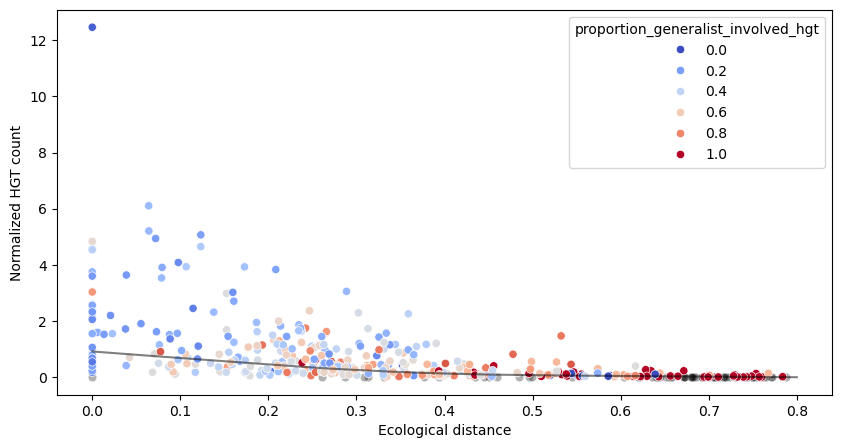

In [10]:
HGTweight_ED_df = plot_hgt_weight_vs_ED(total_HGT_df, specialist_HGT_df, clusterpair_info_df)

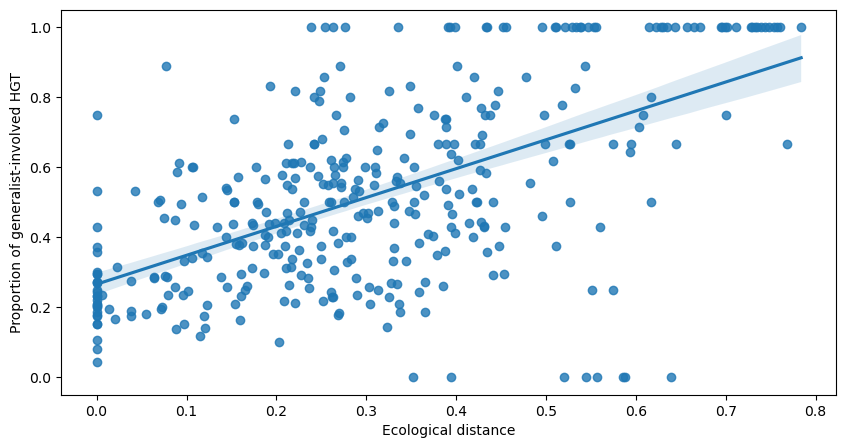

In [11]:
proportion_ED_df = plot_generalist_proportion_vs_ED(total_HGT_df, specialist_HGT_df, clusterpair_info_df)

In [12]:
pearsonr(proportion_ED_df['proportion_generalist_involved_hgt'], proportion_ED_df['ecological_distance'])

PearsonRResult(statistic=0.5890416867419441, pvalue=1.8183636027964535e-35)

In [13]:
spearmanr(proportion_ED_df['proportion_generalist_involved_hgt'], proportion_ED_df['ecological_distance'])

SignificanceResult(statistic=0.5563475549327667, pvalue=4.779193210577083e-31)

## Proportion of Specialist-specialist, Specialist-generalist, Generalist-generalist HGT

In [14]:
# Calculate normalized hgt score for all detected HGT events -> result column: total_HGT_score
all_ctidx = set(cotransfer_annotation_df['co-transfer_index'])
all_HGT_df = get_hgt_scores(total_ctidx, HGT_GENOMEPAIR_FILENAME, cluster_to_mag_count)
all_HGT_df.columns = ['cluster1','cluster2','hgt_count','total_HGT_score']
all_HGT_df = all_HGT_df[['cluster1','cluster2','total_HGT_score']]

# Select horizontal gene transfer events that occur only between specialists -> result column: ss_HGT_score
ss_ctidx = set(cotransfer_annotation_df[cotransfer_annotation_df['max_generalism_score'] < GENERALISM_CUTOFF]['co-transfer_index'])
ss_HGT_df = get_hgt_scores(ss_ctidx, HGT_GENOMEPAIR_FILENAME, cluster_to_mag_count)
ss_HGT_df.columns = ['cluster1','cluster2','hgt_count','ss_HGT_score']
ss_HGT_df = ss_HGT_df[['cluster1','cluster2','ss_HGT_score']]

# Select horizontal gene transfer events that include both generalists and specialists -> result column: sg_HGT_score
sg_HGT_ctidx = set(cotransfer_annotation_df[
                   (cotransfer_annotation_df['max_generalism_score'] >= GENERALISM_CUTOFF) &
                   (cotransfer_annotation_df['min_generalism_score'] < GENERALISM_CUTOFF)
                   ]['co-transfer_index'])
sg_HGT_df = get_hgt_scores(sg_HGT_ctidx, HGT_GENOMEPAIR_FILENAME, cluster_to_mag_count)
sg_HGT_df.columns = ['cluster1','cluster2','hgt_count','sg_HGT_score']
sg_HGT_df = sg_HGT_df[['cluster1','cluster2','sg_HGT_score']]

# Select horizontal gene transfer events that occur only between generalists -> result column: gg_HGT_score
gg_HGT_ctidx = set(cotransfer_annotation_df[cotransfer_annotation_df['min_generalism_score'] >= GENERALISM_CUTOFF]['co-transfer_index'])
gg_HGT_df = get_hgt_scores(gg_HGT_ctidx, HGT_GENOMEPAIR_FILENAME, cluster_to_mag_count)
gg_HGT_df.columns = ['cluster1','cluster2','hgt_count','gg_HGT_score']
gg_HGT_df = gg_HGT_df[['cluster1','cluster2','gg_HGT_score']]

In [15]:
ed_hgt_weight_merged_df = clusterpair_info_df.merge(ss_HGT_df, on=['cluster1','cluster2'], how='outer')
ed_hgt_weight_merged_df = ed_hgt_weight_merged_df.merge(sg_HGT_df, on=['cluster1','cluster2'], how='outer')
ed_hgt_weight_merged_df = ed_hgt_weight_merged_df.merge(gg_HGT_df, on=['cluster1','cluster2'], how='outer')
ed_hgt_weight_merged_df = ed_hgt_weight_merged_df.merge(all_HGT_df, on=['cluster1','cluster2'], how='outer').fillna(0)

close_habitat_hgt = ed_hgt_weight_merged_df[ed_hgt_weight_merged_df['ecological_distance'] < ECOLOGICAL_DISTANCE_CUTOFF]
disparate_habitat_hgt = ed_hgt_weight_merged_df[ed_hgt_weight_merged_df['ecological_distance'] >= ECOLOGICAL_DISTANCE_CUTOFF]

In [16]:
print ('Close-habitat HGT & Specialist-specialist ' + str(close_habitat_hgt['ss_HGT_score'].sum() / close_habitat_hgt['total_HGT_score'].sum()))
print ('Close-habitat HGT & Specialist-generalist ' + str(close_habitat_hgt['sg_HGT_score'].sum() / close_habitat_hgt['total_HGT_score'].sum()))
print ('Close-habitat HGT & Generalist-generalist ' + str(close_habitat_hgt['gg_HGT_score'].sum() / close_habitat_hgt['total_HGT_score'].sum()))

print ('Disparate-habitat HGT & Specialist-specialist ' + str(disparate_habitat_hgt['ss_HGT_score'].sum() / disparate_habitat_hgt['total_HGT_score'].sum()))
print ('Disparate-habitat HGT & Specialist-generalist ' + str(disparate_habitat_hgt['sg_HGT_score'].sum() / disparate_habitat_hgt['total_HGT_score'].sum()))
print ('Disparate-habitat HGT & Generalist-generalist ' + str(disparate_habitat_hgt['gg_HGT_score'].sum() / disparate_habitat_hgt['total_HGT_score'].sum()))

Close-habitat HGT & Specialist-specialist 0.5548763332785369
Close-habitat HGT & Specialist-generalist 0.4442479648830421
Close-habitat HGT & Generalist-generalist 0.0008757018384209133
Disparate-habitat HGT & Specialist-specialist 0.1433947760568474
Disparate-habitat HGT & Specialist-generalist 0.8566052239431526
Disparate-habitat HGT & Generalist-generalist 0.0


## Family removal analysis

In [17]:
def get_unique_HGT(HGT_result_filename, exclude_inferred=True):
    prefix_to_rank = {'d':'domain', 'p':'phylum', 'c':'class', 'o':'order', 'f':'family', 'g':'genus', 's':'species'}
    
    unique_HGTs = set()
    rank_taxon_to_unique_HGTs = {'domain':defaultdict(set),
        'phylum':defaultdict(set),
        'class':defaultdict(set),
        'order':defaultdict(set),
        'family':defaultdict(set),
        'genus':defaultdict(set),
        'species':defaultdict(set)}

    header = True
    with open(HGT_result_filename) as fp:
        for line in fp:
            if header:
                header=False
                continue

            ctidx, ct_length, sp1_short, sp2_short, gscore_1, gscore_2, genome1, genome2, hc1, hc2, distance, inferred = line.strip().split("\t")
    
            if exclude_inferred and inferred=='True':
                continue
            
            ctidx = int(ctidx)
            cluster_pair = "\t".join(sorted([hc1, hc2]))
            sp1_full_taxonomy = species_to_full_taxonomy[sp1_short]
            sp2_full_taxonomy = species_to_full_taxonomy[sp2_short]
    
            unique_HGT = (sp1_short, sp2_short, ctidx, cluster_pair)
            unique_HGTs.add(unique_HGT)
            
            for taxon in sp1_full_taxonomy.split(';'):
                rank = prefix_to_rank[taxon[0]]
                rank_taxon_to_unique_HGTs[rank][taxon].add(unique_HGT)
            
            for taxon in sp2_full_taxonomy.split(';'):
                rank = prefix_to_rank[taxon[0]]
                rank_taxon_to_unique_HGTs[rank][taxon].add(unique_HGT)
    
    
    return unique_HGTs, rank_taxon_to_unique_HGTs


def HGT_weight_taxa_removed(unique_HGTs, taxon_to_unique_HGTs, taxa_to_remove, cluster_to_mag_count, scaling_constant=1_000_000):

    valid_unique_HGTs = unique_HGTs
    for taxon in taxa_to_remove:
        valid_unique_HGTs = valid_unique_HGTs - taxon_to_unique_HGTs[taxon]
        
    cluster_pair_to_ctidxs = defaultdict(set)
    for (sp1, sp2, ctidx, cluster_pair) in valid_unique_HGTs:
        cluster_pair_to_ctidxs[cluster_pair].add(ctidx)
        

    habitat_clusters = ['HTS', 'OLL', 'OIL', 'OHL', 'POL', 'EST', 'FRW', 'TEH', 'TER', 'TEG',
                        'ADC', 'HOR', 'HUV', 'HSS', 'BLD', 'HET', 'WT1', 'ANI', 'MOG', 'RMG',
                        'CKG', 'APG', 'HG1', 'MKG', 'PG1', 'PG2', 'WT2', 'HG2', 'HG3', 'HG4',
                        'HG5', 'HG6', 'HG7', 'NBG', 'IFG', 'CDG', 'BG1', 'BG2', 'BG3', 'HRG']

    cluster_pair_hgt_score_aslist = list()
    for hc1, hc2 in combinations_with_replacement(habitat_clusters, 2):
        hc1, hc2 = sorted([hc1, hc2])
        cluster_pair = "\t".join([hc1, hc2])
        if cluster_pair in cluster_pair_to_ctidxs:
            HGT_count = len(cluster_pair_to_ctidxs[cluster_pair])
        else:
            HGT_count = 0
        
        hc1_mag_count = cluster_to_mag_count[hc1]
        hc2_mag_count = cluster_to_mag_count[hc2]
        normalizing_factor = scaling_constant / (hc1_mag_count * hc2_mag_count)
        normalized_score = HGT_count * normalizing_factor
        cluster_pair_hgt_score_aslist.append([hc1, hc2, HGT_count, normalized_score])

    cluster_pair_hgt_score_df = pd.DataFrame(cluster_pair_hgt_score_aslist, columns = ['cluster1','cluster2','HGT_count','normalized_HGT_count'])

    return cluster_pair_hgt_score_df

def line_and_bar_dualaxes_plot(df, x_axis, y_axis1, y_axis2, save=None):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Bar chart on ax1 for 'p5'
    bars = ax1.bar(df[x_axis], df[y_axis1], color='lightblue', label=y_axis1, alpha=0.7)
    ax1.set_ylabel(y_axis1, color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xticklabels(df[x_axis], rotation=45, ha='right')
    ax1.set_ylim([0, 0.5])
    
    # Create a second y-axis
    ax2 = ax1.twinx()
    
    # Line + scatter plot on ax2 for 'proportion_retained'
    ax2.plot(df[x_axis], df[y_axis2], color='red', marker='o', label=y_axis2, zorder=10)
    ax2.set_ylabel(y_axis2, color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0, 1])
    
    # Make sure the line and scatter are in front
    for line in ax2.get_lines():
        line.set_zorder(10)
    for path in ax2.collections:  # This includes scatter points
        path.set_zorder(11)
    
    plt.tight_layout()
    
    if save != None:
        plt.savefig(save)
        
    plt.show()

In [18]:
unique_HGTs, rank_taxon_to_unique_HGTs = get_unique_HGT(HGT_GENOMEPAIR_FILENAME , exclude_inferred=False)

In [19]:
alltaxa_HGT_weight = HGT_weight_taxa_removed(unique_HGTs, rank_taxon_to_unique_HGTs['domain'], {}, cluster_to_mag_count)
alltaxa_HGT_merged = alltaxa_HGT_weight.merge(clusterpair_info_df, on=['cluster1', 'cluster2'], how='outer')
alltaxa_HGT_valid = alltaxa_HGT_merged[alltaxa_HGT_merged['validity_pair']]
alltaxa_HGT_total_weight_sum = alltaxa_HGT_valid['normalized_HGT_count'].sum()
alltaxa_HGT_disparate_weight_sum = alltaxa_HGT_valid[alltaxa_HGT_valid['ecological_distance'] >= ECOLOGICAL_DISTANCE_CUTOFF]['normalized_HGT_count'].sum()

In [20]:
# by removing individual taxon, calculate how much of total and disparate-habitat horizontal gene tranfers are reduced.
# This part will take several hours to calculate, precalculated result can be found 
# ./data/rank_taxon_to_HGT_contribution.tsv

'''
ranks = ['domain','phylum','class','order','family','genus', 'species']

rank_taxon_HGT_contribution_aslist = list()
for rank in ranks:
    taxa = rank_taxon_to_unique_HGTs[rank].keys()
    for taxon in taxa:
        taxon_removed_HGT_weight = HGT_weight_taxa_removed(unique_HGTs, rank_taxon_to_unique_HGTs[rank], {taxon}, cluster_to_mag_count, scaling_constant=1_000_000)
        taxon_removed_merged = taxon_removed_HGT_weight.merge(clusterpair_info_df, on=['cluster1', 'cluster2'])
        taxon_removed_valid = taxon_removed_merged[taxon_removed_merged['validity_pair']]
        
        taxon_removed_total_weight_sum = taxon_removed_valid['normalized_HGT_count'].sum()
        taxon_removed_total_disparate_weight_sum = taxon_removed_valid[taxon_removed_valid['ecological_distance'] >= ECOLOGICAL_DISTANCE_CUTOFF]['normalized_HGT_count'].sum()
        
        reduced_rate_total = (alltaxa_HGT_total_weight_sum - taxon_removed_total_weight_sum) / alltaxa_HGT_total_weight_sum
        reduced_rate_disparate = (alltaxa_HGT_disparate_weight_sum - taxon_removed_total_disparate_weight_sum) / alltaxa_HGT_disparate_weight_sum
        
        rank_taxon_HGT_contribution_aslist.append([rank, taxon, reduced_rate_total, reduced_rate_disparate])
            
rank_taxon_to_HGT_contribution_df = pd.DataFrame(rank_taxon_HGT_contribution_aslist, columns = ['rank','taxon','reduced_rate_total_HGT','reduced_rate_disparate_HGT'])
'''

rank_taxon_to_HGT_contribution_df = pd.read_csv('./data/rank_taxon_to_HGT_contribution.tsv', sep='\t')

In [21]:
rank = 'family'
top_n = 10

# get [top_n] [rank] taxa with the most contribution to disparate-habiatt HGT
top_taxa =  rank_taxon_to_HGT_contribution_df[rank_taxon_to_HGT_contribution_df['rank'] == rank].sort_values(by='reduced_rate_disparate_HGT', ascending=False).head(top_n)['taxon'].to_list()

In [22]:
#This is to calculate how much diprate-habitat horizontal gene transfer will be reduced by cumulative remonal of top taxa.

result_as_list = [['total', alltaxa_HGT_disparate_weight_sum, 1]]

for i in range(len(top_taxa)):
    removed_taxon = top_taxa[i]
    to_remove_cumulative = set(top_taxa[:i+1])
    taxa_removed_HGT_weight = HGT_weight_taxa_removed(unique_HGTs, rank_taxon_to_unique_HGTs[rank], to_remove_cumulative, cluster_to_mag_count)
    taxa_removed_merged = taxa_removed_HGT_weight.merge(clusterpair_info_df, on=['cluster1', 'cluster2'])
    taxa_removed_valid = taxa_removed_merged[taxa_removed_merged['validity_pair']]
    
    taxa_removed_total_weight_sum = taxa_removed_valid['normalized_HGT_count'].sum()
    taxa_removed_total_disparate_weight_sum = taxa_removed_valid[taxa_removed_valid['ecological_distance'] >= ECOLOGICAL_DISTANCE_CUTOFF]['normalized_HGT_count'].sum()

    result_as_list.append([removed_taxon, taxa_removed_total_disparate_weight_sum, taxa_removed_total_disparate_weight_sum/alltaxa_HGT_disparate_weight_sum])

retained_longD_HGT_df = pd.DataFrame(result_as_list, columns = ['taxon', 'retained_HGT_weight', 'proportion_retained'])

In [23]:
individual_cumulative_merged_df = retained_longD_HGT_df.merge(
    rank_taxon_to_HGT_contribution_df[rank_taxon_to_HGT_contribution_df['taxon'].isin(top_taxa)]
    ,on='taxon',  how='outer')

/tmp/ipykernel_3922686/1526404292.py:91: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(df[x_axis], rotation=45, ha='right')


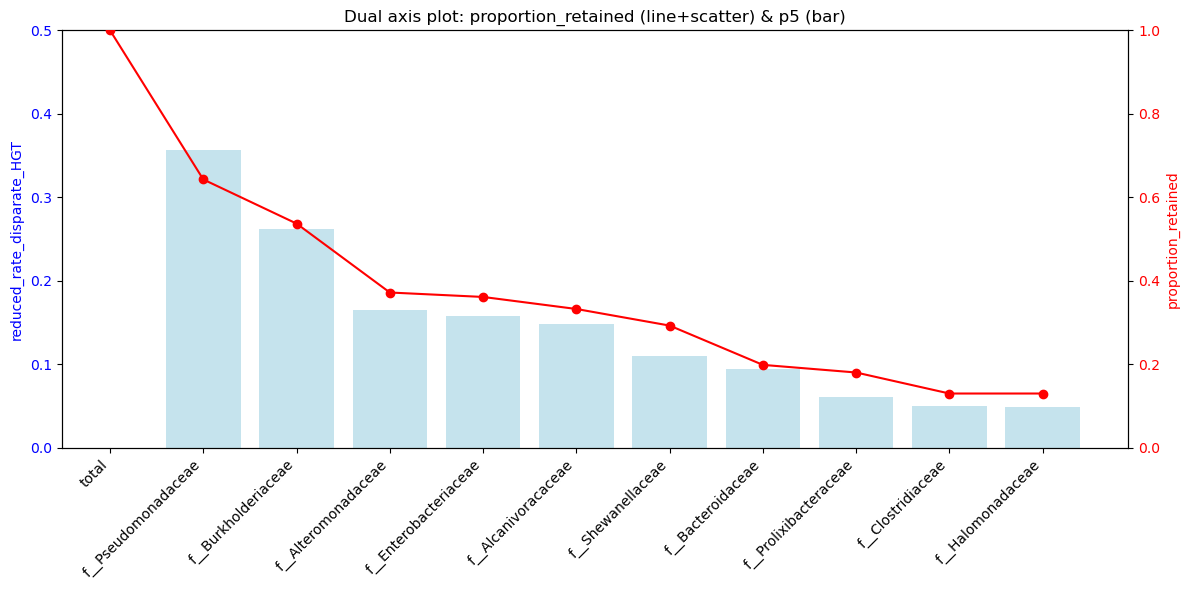

In [23]:
line_and_bar_dualaxes_plot(individual_cumulative_merged_df, x_axis='taxon', y_axis1='reduced_rate_disparate_HGT', y_axis2='proportion_retained')